<a href="https://colab.research.google.com/github/maiaramai319-art/Amostragem/blob/main/ANOVA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A Análise de Variância (ANOVA) é uma técnica estatística robusta que tem como objetivo fundamental comparar as médias de três ou mais grupos de dados para determinar se as diferenças observadas entre eles são estatisticamente significativas ou se ocorreram apenas por acaso (ruído aleatório/erro experimental).

O significado "escondido" no nome é o seu maior trunfo: em vez de apenas olhar para a média final, a ANOVA analisa como a variabilidade total dos seus dados é distribuída. Ela decompõe essa variabilidade em duas fontes principais:

Variabilidade Devido ao Tratamento (Diferença entre Grupos): A variação causada pelas mudanças que você fez (como alterar a temperatura ou o teor de argila).

Variabilidade Devido ao Erro (Diferença dentro dos Grupos): A variação natural e inevitável inerente à moldagem, ensaio e equipamentos de laboratório.

Ela utiliza o Teste F para comparar essas duas variâncias. Se a variabilidade gerada pelas suas escolhas de design for muito maior que a variabilidade aleatória, a ANOVA conclui que o seu fator teve um efeito real e significativo.
  



              TABELA ANOVA DE DOIS FATORES
                                 sum_sq    df          F        PR(>F)
C(Teor_Argila)                 5.193339   2.0  51.165900  6.537157e-10
C(Temperatura)                 7.626906   2.0  75.141927  9.255009e-12
C(Teor_Argila):C(Temperatura)  7.383461   4.0  36.371730  1.660205e-10
Residual                       1.370250  27.0        NaN           NaN




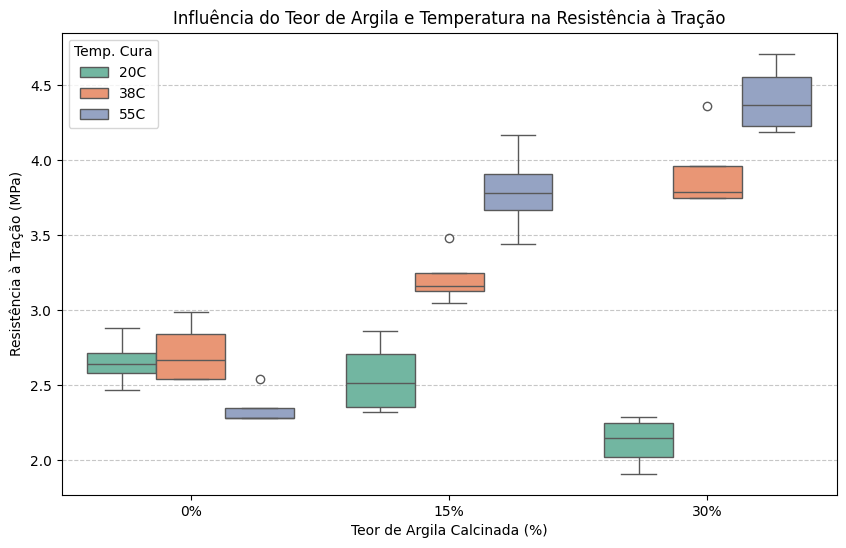

In [6]:
# 1. Importar as bibliotecas necessárias
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Configurar semente aleatória para resultados repetíveis
np.random.seed(42)

# 3. Simular os dados do experimento de tração (MPa)
# Criando combinações de fatores com 4 repetições (corpos de prova) por grupo
teores = ['0%', '15%', '30%']
temperaturas = ['20C', '38C', '55C']
n_repeticoes = 4

dados = []

# Médias hipotéticas para simular que a temperatura alta ativa a argila
medias_resistencia = {
    ('0%', '20C'): 2.5, ('0%', '38C'): 2.6, ('0%', '55C'): 2.4,
    ('15%', '20C'): 2.8, ('15%', '38C'): 3.4, ('15%', '55C'): 3.8,
    ('30%', '20C'): 2.2, ('30%', '38C'): 3.9, ('30%', '55C'): 4.5
}

for t_argila in teores:
    for temp in temperaturas:
        media = i_media = medias_resistencia[(t_argila, temp)]
        # Adiciona ruído aleatório (desvio padrão de 0.25 MPa) para simular o laboratório
        valores_tracao = np.random.normal(loc=media, scale=0.25, size=n_repeticoes)

        for valor in valores_tracao:
            dados.append({
                'Teor_Argila': t_argila,
                'Temperatura': temp,
                'Tracao_MPa': round(valor, 2)
            })

df = pd.DataFrame(dados)

# 4. Executar a ANOVA de Dois Fatores (Two-Way ANOVA)
# A fórmula indica: Tracao depende de Argila + Temperatura + Interação entre ambas (*)
modelo = ols('Tracao_MPa ~ C(Teor_Argila) * C(Temperatura)', data=df).fit()
tabela_anova = sm.stats.anova_lm(modelo, typ=2)

print("="*60)
print("              TABELA ANOVA DE DOIS FATORES")
print("="*60)
print(tabela_anova)
print("\n" + "="*60 + "\n")

# 5. Teste de Comparação Múltipla (Tukey) se houver significância
# Criando uma coluna combinada para avaliar as interações par a par
df['Grupo_Combinado'] = df['Teor_Argila'] + "_" + df['Temperatura']
tukey = pairwise_tukeyhsd(endog=df['Tracao_MPa'], groups=df['Grupo_Combinado'], alpha=0.05)

# 6. Visualização Gráfica dos Resultados
plt.figure(figsize=(10, 6))
sns.boxplot(x='Teor_Argila', y='Tracao_MPa', hue='Temperatura', data=df, palette='Set2')
plt.title('Influência do Teor de Argila e Temperatura na Resistência à Tração')
plt.xlabel('Teor de Argila Calcinada (%)')
plt.ylabel('Resistência à Tração (MPa)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Temp. Cura')
plt.show()